<a href="https://colab.research.google.com/github/Charithasri20/decision-tree-random-forest/blob/main/day9_decision_tree_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 9 — Decision Tree + Random Forest
## April 11, 2026 — B.Tech AIML 30 Day Challenge

### Topics Covered
- Decision Tree on Iris dataset
- Visualize the tree
- Effect of max_depth on overfitting
- Random Forest with feature importance
- Cross-validation comparison

### Author
B.Tech AIML Graduate — Hyderabad

In [1]:
# Day 9 — Decision Tree + Random Forest
# April 11, 2026

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, cross_val_score
)
from sklearn.tree import (
    DecisionTreeClassifier, plot_tree
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pickle
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported!")

All libraries imported!


## Part 1 — Decision Tree on Iris Dataset

In [2]:
# Load Iris dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"]      = iris.target
df["species_name"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("IRIS DATASET")
print("=" * 50)
print(f"Shape          : {df.shape}")
print(f"Features       : {iris.feature_names}")
print(f"Target classes : {list(iris.target_names)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass distribution:")
print(df["species_name"].value_counts())

IRIS DATASET
Shape          : (150, 6)
Features       : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


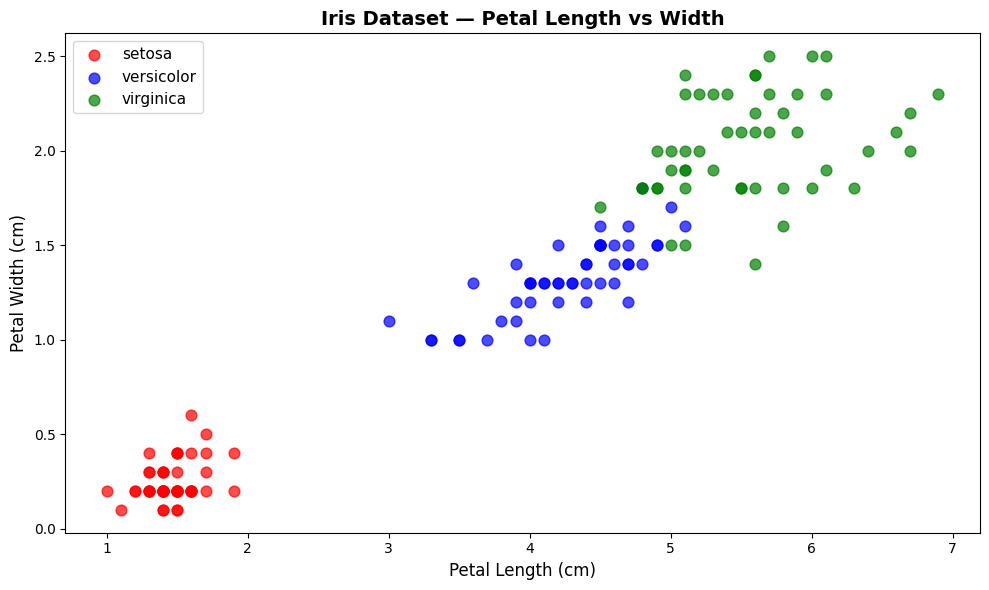

Scatter plot saved
Observation: Setosa is clearly separate


In [3]:
plt.figure(figsize=(10, 6))
colors  = ["red", "blue", "green"]
species = ["setosa", "versicolor", "virginica"]

for i, (sp, color) in enumerate(
    zip(species, colors)
):
    mask = df["species"] == i
    plt.scatter(
        df[mask]["petal length (cm)"],
        df[mask]["petal width (cm)"],
        c=color, label=sp,
        alpha=0.7, s=60
    )

plt.xlabel("Petal Length (cm)", fontsize=12)
plt.ylabel("Petal Width (cm)", fontsize=12)
plt.title("Iris Dataset — Petal Length vs Width",
          fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("iris_scatter.png", dpi=150)
plt.show()
print("Scatter plot saved")
print("Observation: Setosa is clearly separate")

In [4]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y
)

print("TRAIN TEST SPLIT:")
print("=" * 40)
print(f"Total    : {len(X)}")
print(f"Training : {len(X_train)} (80%)")
print(f"Testing  : {len(X_test)}  (20%)")

TRAIN TEST SPLIT:
Total    : 150
Training : 120 (80%)
Testing  : 30  (20%)


In [5]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth  = 3,
    criterion  = "gini",
    random_state = 42
)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print("DECISION TREE RESULTS:")
print("=" * 40)
print(f"Accuracy : {dt_acc:.4f} ({dt_acc:.1%})")
print(f"Depth    : {dt_model.get_depth()}")
print(f"Leaves   : {dt_model.get_n_leaves()}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, dt_pred,
    target_names=iris.target_names
))

DECISION TREE RESULTS:
Accuracy : 0.9667 (96.7%)
Depth    : 3
Leaves   : 5

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



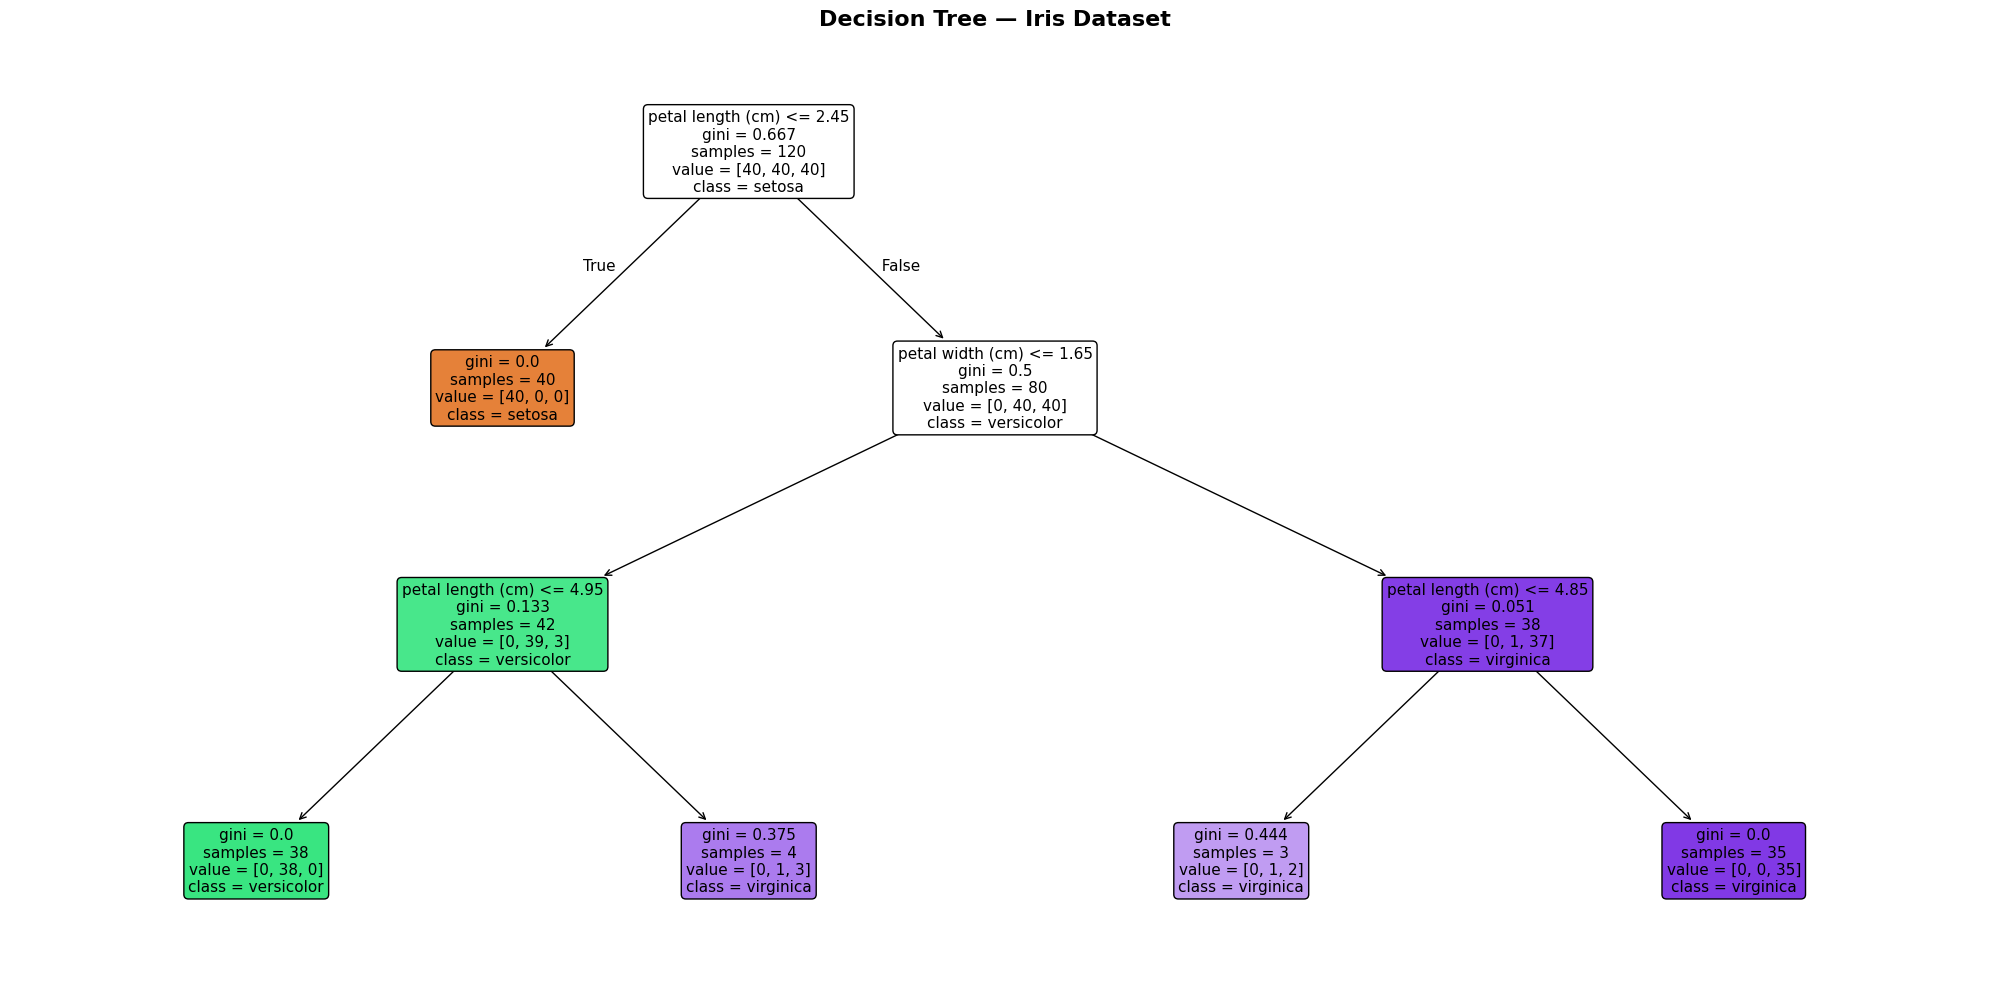

Decision Tree visualization saved

How to read:
Each box = one node
Top line = split condition
gini     = purity of this node
samples  = data points here
value    = count per class
class    = majority class prediction


In [6]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names = iris.feature_names,
    class_names   = iris.target_names,
    filled  = True,
    rounded = True,
    fontsize= 11
)
plt.title("Decision Tree — Iris Dataset",
          fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree_visual.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Decision Tree visualization saved")
print("\nHow to read:")
print("Each box = one node")
print("Top line = split condition")
print("gini     = purity of this node")
print("samples  = data points here")
print("value    = count per class")
print("class    = majority class prediction")

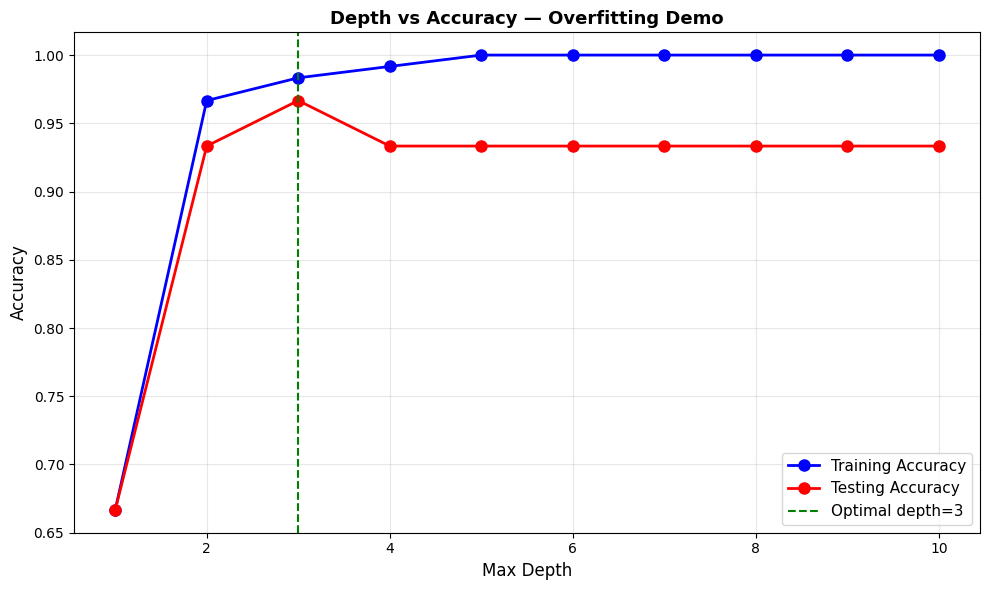

As depth increases training=100%
but test accuracy drops = OVERFITTING


In [7]:
depths       = range(1, 11)
train_scores = []
test_scores  = []

for depth in depths:
    m = DecisionTreeClassifier(
        max_depth=depth, random_state=42
    )
    m.fit(X_train, y_train)
    train_scores.append(
        accuracy_score(y_train, m.predict(X_train))
    )
    test_scores.append(
        accuracy_score(y_test, m.predict(X_test))
    )

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores,
         "b-o", label="Training Accuracy",
         linewidth=2, markersize=8)
plt.plot(depths, test_scores,
         "r-o", label="Testing Accuracy",
         linewidth=2, markersize=8)
plt.axvline(x=3, color="green",
            linestyle="--",
            label="Optimal depth=3")
plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Depth vs Accuracy — Overfitting Demo",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("depth_vs_accuracy.png", dpi=150)
plt.show()
print("As depth increases training=100%")
print("but test accuracy drops = OVERFITTING")

## Part 2 — Random Forest

In [8]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 5,
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS:")
print("=" * 40)
print(f"Accuracy   : {rf_acc:.4f} ({rf_acc:.1%})")
print(f"Num Trees  : {rf_model.n_estimators}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, rf_pred,
    target_names=iris.target_names
))

RANDOM FOREST RESULTS:
Accuracy   : 0.9333 (93.3%)
Num Trees  : 100

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



FEATURE IMPORTANCE:
petal width (cm)              : 0.4381 █████████████████████
petal length (cm)             : 0.4316 █████████████████████
sepal length (cm)             : 0.1160 █████
sepal width (cm)              : 0.0142 


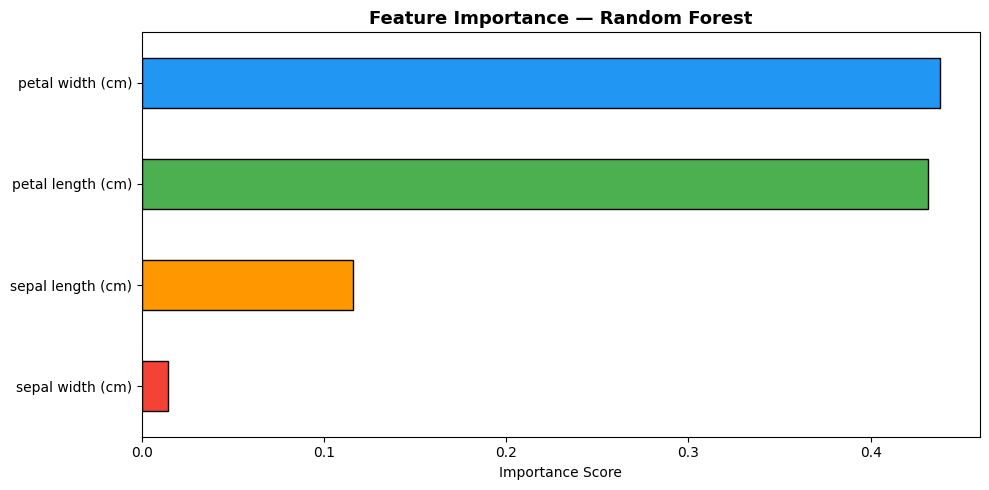

Petal features more important than sepal


In [9]:
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=False)

print("FEATURE IMPORTANCE:")
print("=" * 40)
for feat, imp in feat_imp.items():
    bar = "█" * int(imp * 50)
    print(f"{feat:30}: {imp:.4f} {bar}")

plt.figure(figsize=(10, 5))
feat_imp.sort_values().plot(
    kind="barh",
    color=["#F44336","#FF9800","#4CAF50","#2196F3"],
    edgecolor="black"
)
plt.title("Feature Importance — Random Forest",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Petal features more important than sepal")

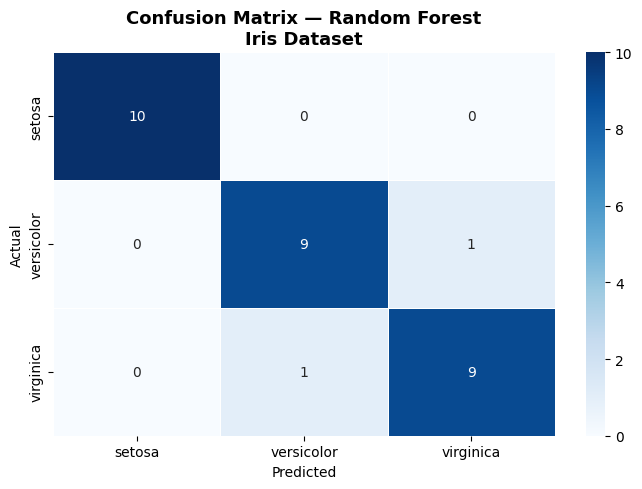


Correct predictions  : 28
Incorrect predictions: 2


In [10]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=0.5)
plt.title("Confusion Matrix — Random Forest\n"
          "Iris Dataset",
          fontsize=13, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()

print(f"\nCorrect predictions  : "
      f"{cm[0][0]+cm[1][1]+cm[2][2]}")
print(f"Incorrect predictions: "
      f"{len(X_test)-(cm[0][0]+cm[1][1]+cm[2][2])}")

CROSS-VALIDATION (5-fold):
Decision Tree : 0.9733 (+/- 0.0249)
Random Forest : 0.9667 (+/- 0.0211)


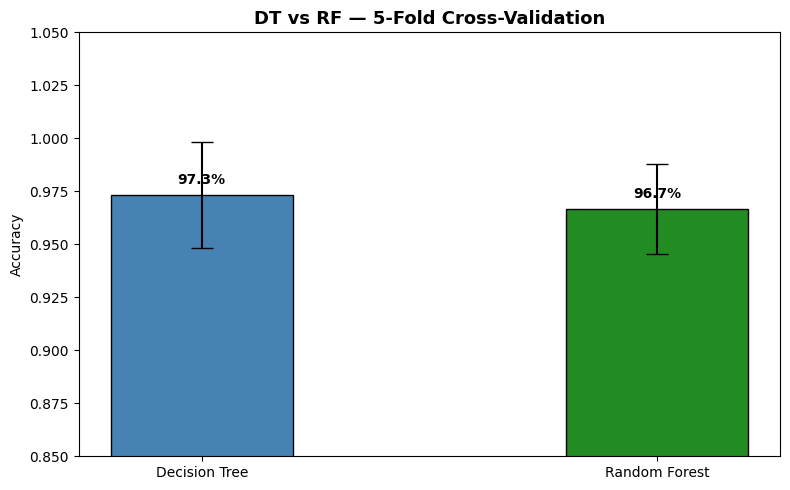

Random Forest more accurate AND more stable


In [11]:
# Cross-validation
dt_cv = cross_val_score(
    DecisionTreeClassifier(
        max_depth=3, random_state=42
    ),
    X, y, cv=5
)
rf_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    X, y, cv=5
)

print("CROSS-VALIDATION (5-fold):")
print("=" * 40)
print(f"Decision Tree : {dt_cv.mean():.4f} "
      f"(+/- {dt_cv.std():.4f})")
print(f"Random Forest : {rf_cv.mean():.4f} "
      f"(+/- {rf_cv.std():.4f})")

# Comparison chart
models    = ["Decision Tree", "Random Forest"]
cv_means  = [dt_cv.mean(), rf_cv.mean()]
cv_stds   = [dt_cv.std(),  rf_cv.std()]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, cv_means,
               yerr=cv_stds,
               color=["steelblue","forestgreen"],
               edgecolor="black",
               capsize=8, width=0.4)
plt.title("DT vs RF — 5-Fold Cross-Validation",
          fontsize=13, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.05)
for bar, mean in zip(bars, cv_means):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{mean:.1%}",
        ha="center", fontweight="bold"
    )
plt.tight_layout()
plt.savefig("dt_vs_rf_comparison.png", dpi=150)
plt.show()
print("Random Forest more accurate AND more stable")

In [12]:
# Save both models
with open("iris_dt_model.pkl", "wb") as f:
    pickle.dump(dt_model, f)
print("Decision Tree saved: iris_dt_model.pkl")

with open("iris_rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Random Forest saved: iris_rf_model.pkl")

# Verify load
with open("iris_rf_model.pkl", "rb") as f:
    loaded = pickle.load(f)
verify = accuracy_score(y_test, loaded.predict(X_test))
print(f"\nLoaded RF accuracy : {verify:.4f}")
print("Save and load verified!")

Decision Tree saved: iris_dt_model.pkl
Random Forest saved: iris_rf_model.pkl

Loaded RF accuracy : 0.9333
Save and load verified!


In [13]:
new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],  # likely setosa
    [6.3, 2.8, 4.5, 1.5],  # likely versicolor
    [7.2, 3.0, 5.8, 1.8],  # likely virginica
])

preds = rf_model.predict(new_flowers)
probs = rf_model.predict_proba(new_flowers)

print("PREDICTIONS FOR NEW FLOWERS:")
print("=" * 60)
for i, (pred, prob) in enumerate(
    zip(preds, probs)
):
    species    = iris.target_names[pred]
    confidence = prob.max()
    print(f"\nFlower {i+1}: {new_flowers[i]}")
    print(f"  Predicted  : {species.upper()}")
    print(f"  Confidence : {confidence:.1%}")
    print(f"  All probs  : "
          f"setosa={prob[0]:.2f}, "
          f"versicolor={prob[1]:.2f}, "
          f"virginica={prob[2]:.2f}")

PREDICTIONS FOR NEW FLOWERS:

Flower 1: [5.1 3.5 1.4 0.2]
  Predicted  : SETOSA
  Confidence : 100.0%
  All probs  : setosa=1.00, versicolor=0.00, virginica=0.00

Flower 2: [6.3 2.8 4.5 1.5]
  Predicted  : VERSICOLOR
  Confidence : 95.2%
  All probs  : setosa=0.00, versicolor=0.95, virginica=0.05

Flower 3: [7.2 3.  5.8 1.8]
  Predicted  : VIRGINICA
  Confidence : 100.0%
  All probs  : setosa=0.00, versicolor=0.00, virginica=1.00
